# Machine Learning-Based Fraud Detection System for NovaPay

# NovaPay Fraud Detection Project

## 1. Business Understanding

NovaPay is a digital-first cross-border money transfer company. The company needs a machine learning-based fraud detection system to identify suspicious transactions, reduce financial loss, reduce false positives, and support real-time fraud monitoring.

The target variable for this project is `is_fraud`, where:

- 0 = Legitimate transaction
- 1 = Fraudulent transaction

# Day 1 Deliverable

## Data Collection and Profiling

# Data Collection and Profiling

The NovaPay dataset was loaded into a Pandas DataFrame for initial profiling and assessment. Data profiling was performed to understand the dataset structure, identify data types, detect missing values, and assess overall data quality before proceeding to data cleaning and feature engineering.

# Dataset Loaading

In [1]:
import pandas as pd

df = pd.read_csv("nova_pay_combined.csv")

In [2]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [3]:
df.shape

(11400, 26)

### Dataset Dimensions

The dataset contains 11,400 transaction records and 26 variables describing transaction characteristics, customer attributes, device information, behavioral indicators, and fraud outcomes.

In [4]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

### Feature Overview

The dataset contains transaction-level, customer-level, device-level, and behavioral features. The target variable for fraud prediction is `is_fraud`, where:

- 0 = Legitimate transaction
- 1 = Fraudulent transaction

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

### Data Structure Assessment

The dataset contains a mixture of categorical, numerical, and Boolean variables.

Data Types Identified:

- Object: Transaction IDs, customer IDs, countries, currencies, channels, and other categorical fields.
- Float64: Transaction amounts, fees, risk scores, exchange rates, and trust scores.
- Int64: Account age, transaction velocity metrics, fraud labels, and chargeback counts.
- Boolean: New device indicators and location mismatch indicators.

The presence of multiple data types suggests that preprocessing and encoding will be required before model development.

In [6]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

timestamp              29
amount_usd            305
fee                   295
ip_address            305
ip_country            301
kyc_tier              300
device_trust_score    295
dtype: int64

### Missing Values Assessment

An assessment of missing values revealed that seven variables contain incomplete observations.

| Variable | Missing Values |
|-----------|-----------:|
| timestamp | 29 |
| amount_usd | 305 |
| fee | 295 |
| ip_address | 305 |
| ip_country | 301 |
| kyc_tier | 300 |
| device_trust_score | 295 |

The remaining variables contain complete observations with no missing values.

The highest proportion of missing values occurs in amount_usd and ip_address (305 records each). These missing values will require further investigation and treatment during the data cleaning phase.

In [8]:
df.duplicated().sum()

np.int64(200)

### Duplicate Records Assessment

A duplicate record assessment was performed to evaluate data quality and integrity.

The dataset contains 200 duplicate transaction records.

Duplicate records can distort transaction patterns, bias model training, and affect fraud detection performance. These duplicate observations will be investigated and appropriately handled during the data cleaning phase.

### Data Quality Overview

The initial data quality assessment revealed the presence of missing values and duplicate records within the dataset. These issues are common in real-world financial transaction data and will be addressed during the data cleaning phase. Overall, the dataset appears suitable for fraud detection modeling and further exploratory analysis.

# Day 1 Summary

The NovaPay dataset was successfully loaded and profiled.

Key findings include:

- The dataset contains 11,400 transaction records and 26 variables.
- The target variable is `is_fraud`, representing legitimate and fraudulent transactions.
- Multiple data types are present, including categorical, numerical, and Boolean variables.
- Seven variables contain missing values that will require treatment during data cleaning.
- The dataset contains 200 duplicate records that may affect model performance if left untreated.
- Initial profiling confirms that the dataset is suitable for supervised machine learning classification.

The next phase will focus on Data Sources and Initial Assessment, including fraud distribution analysis, class imbalance assessment, and exploratory analysis of transaction behavior.

# Day 2

## Data Sources & Initial Assessment

### Understanding the Target Variable

is_fraud

Where:
- 0 = Legitimate Transaction 
- 1 = Fraudulent Transaction

In [9]:
df["is_fraud"].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [10]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    91.254386
1     8.745614
Name: proportion, dtype: float64

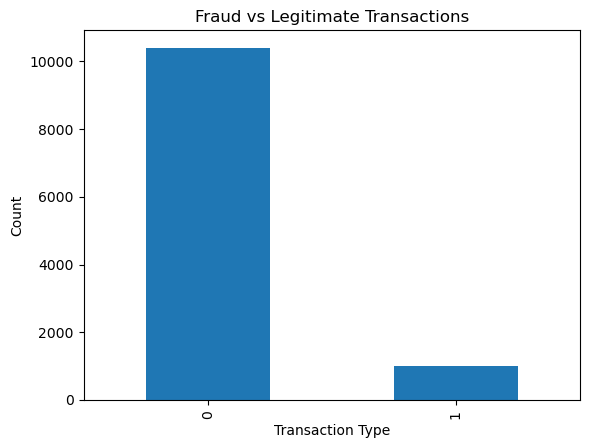

In [11]:
import matplotlib.pyplot as plt

df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# Fraud Distribution Assessment

The target variable (is_fraud) was analyzed to understand the distribution of legitimate and fraudulent transactions within the dataset.

Results show:

- Legitimate transactions: 10,403
- Fraudulent transactions: 997
- Fraud rate: 8.75%
- Legitimate transaction rate: 91.25%

The dataset is moderately imbalanced, with legitimate transactions significantly outnumbering fraudulent transactions. However, the fraud class remains sufficiently represented for supervised machine learning model development.

The class distribution suggests that special attention may be required during model training to ensure fraudulent transactions are correctly identified and not overshadowed by the majority class.

In [12]:
fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 8.75%


In [13]:
df["channel"].value_counts()

channel
mobile       6366
web          3727
ATM          1008
mobille        60
 mobile        48
MOBILE         47
unknown        37
WEB            36
 web           34
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64

In [14]:
df.groupby("channel")["is_fraud"].mean() * 100

channel
 ATM          0.000000
 mobile       0.000000
 web          5.882353
ATM           7.936508
ATm          11.111111
MOBILE        0.000000
WEB           5.555556
mobile        4.712535
mobille       0.000000
unknown       2.702703
web          16.393882
weeb          0.000000
Name: is_fraud, dtype: float64

# Transaction Channel Assessment

The transaction channel distribution was analyzed to understand customer transaction behavior across different platforms.

The majority of transactions were conducted through mobile and web channels, with ATM transactions representing a smaller proportion of overall activity.

The channel variable contains inconsistent values, including capitalization differences (e.g., "web" and "WEB") and potential spelling errors (e.g., "weeb" instead of "web"). These inconsistencies suggest data quality issues that will be addressed during the data cleaning phase.

In [15]:
df["home_country"].value_counts().head(10)

home_country
US         7940
UK         2119
CA         1221
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

In [16]:
df.groupby("home_country")["is_fraud"].mean().sort_values(ascending=False).head(10) * 100

home_country
CA         15.151515
UK         13.308164
US          6.662469
unknown     3.125000
 US         0.000000
 CA         0.000000
 UK         0.000000
Name: is_fraud, dtype: float64

# Country Distribution Assessment

Home country analysis revealed that transaction activity is concentrated in a small number of countries, primarily the United States (7,940 transactions), United Kingdom (2,119 transactions), and Canada (1,221 transactions).

The assessment also revealed inconsistent country representations such as "CA" and "ca", as well as "UK" and "uk". These inconsistencies will be addressed during data preparation to ensure accurate aggregation and modeling.

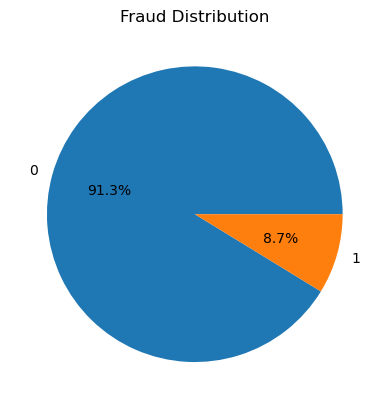

In [17]:
df["is_fraud"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Fraud Distribution")
plt.ylabel("")
plt.show()

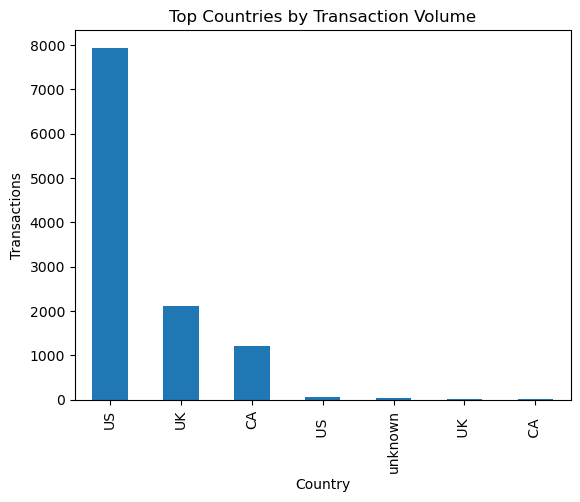

In [18]:
df["home_country"].value_counts().head(10).plot(kind="bar")
plt.title("Top Countries by Transaction Volume")
plt.xlabel("Country")
plt.ylabel("Transactions")
plt.show()

# Key Findings
- The dataset contains 11,400 transactions.
- Fraudulent transactions represent 8.75% of all observations.
- Legitimate transactions represent 91.25% of all observations.
- Mobile and web channels account for the majority of transaction activity.
- The United States generates the highest transaction volume, followed by the United Kingdom and Canada.
- Data quality issues were identified in channel and country variables due to inconsistent capitalization.
- The dataset remains suitable for machine learning modeling after data cleaning and preparation.

# Day 2 Summary

The NovaPay dataset was further assessed to understand fraud prevalence, transaction behavior, and data quality characteristics.

The analysis confirmed that fraud represents a minority class (8.75%), indicating moderate class imbalance. Transaction activity is concentrated in mobile and web channels and is largely generated from the United States, United Kingdom, and Canada.

Several data quality issues were identified, including inconsistent categorical values within channel and country variables. These findings provide important direction for the next phase of the project, which will focus on data cleaning, preprocessing, and feature preparation.

# Day 3: Data Cleaning and Preparation

## Objective

The objective of Day 3 is to clean and prepare the NovaPay fraud detection dataset for further analysis and machine learning modeling.

This stage focuses on:

- Creating a clean working copy of the dataset
- Removing duplicate records
- Handling missing values
- Standardizing inconsistent categorical values
- Converting appropriate data types
- Validating the cleaned dataset

In [19]:
# Create a copy of the original dataset for cleaning
df_clean = df.copy()

## 1. Initial Dataset Check

Before cleaning, the dataset shape is checked to confirm the number of records and variables.

In [20]:
df_clean.shape

(11400, 26)

## 2. Duplicate Records Assessment

Duplicate records are checked because repeated transactions can distort fraud patterns and negatively affect model performance.

In [21]:
df_clean.duplicated().sum()

np.int64(200)

## 3. Removing Duplicate Records

The duplicate records identified in the dataset are removed to improve data quality.

In [22]:
df_clean = df_clean.drop_duplicates()

In [23]:
df_clean.duplicated().sum()

np.int64(0)

In [24]:
df_clean.shape

(11200, 26)

### Duplicate Removal Outcome

The duplicate records were successfully removed.

Dataset shape changed from:

- Before cleaning: 11,400 records
- After cleaning: 11,200 records

This confirms that all 200 duplicate observations were removed while preserving all 26 variables.

## 4. Missing Values Assessment

Missing values were evaluated to identify incomplete observations that may affect model performance and analytical accuracy.

Understanding the extent of missing data is important for determining appropriate data treatment strategies before model development.

In [25]:
df_clean.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [26]:
missing_values = df_clean.isnull().sum()

missing_values[missing_values > 0]

timestamp              29
amount_usd            300
fee                   290
ip_address            300
ip_country            296
kyc_tier              295
device_trust_score    290
dtype: int64

### Missing Values Summary

The following variables contain missing observations:

| Variable | Missing Values |
|-----------|---------------|
| timestamp | 29 |
| amount_usd | 300 |
| fee | 290 |
| ip_address | 300 |
| ip_country | 296 |
| kyc_tier | 295 |
| device_trust_score | 290 |

The remaining variables contain complete observations with no missing values.

The variables amount_usd and ip_address contain the highest number of missing records and will require appropriate treatment during the data preparation stage.

## 5. Missing Values Treatment Strategy

Before handling missing values, each affected variable was evaluated to determine the most appropriate treatment method based on its data type and business meaning.

The goal is to preserve as much useful information as possible while minimizing the impact of incomplete observations.

### Numerical Variables with Missing Values

The following numerical variables contain missing values:

- amount_usd
- fee
- device_trust_score

Since these variables represent continuous numerical measurements, missing values will be replaced using the median value to reduce the influence of outliers.

In [27]:
num_cols = ["amount_usd", "fee", "device_trust_score"]

df_clean[num_cols].median()

amount_usd            163.4850
fee                     3.5000
device_trust_score      0.6545
dtype: float64

### Categorical Variables with Missing Values

The following categorical variables contain missing values:

- ip_country
- kyc_tier

Missing values in these variables will be replaced using the most frequent category (mode) to preserve existing patterns.

In [28]:
cat_cols = ["ip_country", "kyc_tier"]

for col in cat_cols:
    print(col)
    print(df_clean[col].mode()[0])

ip_country
US
kyc_tier
standard


### Timestamp Variable

The timestamp variable contains only a small number of missing observations.

Because transaction time is critical for fraud analysis and cannot be reliably inferred, records with missing timestamps will be removed.

### IP Address Variable

IP addresses represent unique identifiers rather than measurable values.

Missing IP addresses will be replaced with the placeholder value "Unknown" to preserve records while clearly identifying missing information.

In [29]:
df_clean[num_cols].median()

amount_usd            163.4850
fee                     3.5000
device_trust_score      0.6545
dtype: float64

In [30]:
for col in cat_cols:
    print(col)
    print(df_clean[col].mode()[0])

ip_country
US
kyc_tier
standard


## 6. Handling Missing Values

Based on the missing value assessment, different treatment strategies were applied depending on the nature of each variable.

### Treatment Strategy

- Numerical variables were imputed using the median value.
- Categorical variables were imputed using the most frequent category (mode).
- Missing IP addresses were replaced with "Unknown".
- Records with missing timestamps were removed because transaction time is essential for fraud analysis.

In [31]:
num_cols = ["amount_usd", "fee", "device_trust_score"]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [32]:
df_clean["ip_country"] = df_clean["ip_country"].fillna("US")

df_clean["kyc_tier"] = df_clean["kyc_tier"].fillna("standard")

In [33]:
df_clean["ip_address"] = df_clean["ip_address"].fillna("Unknown")

In [34]:
df_clean = df_clean.dropna(subset=["timestamp"])

In [35]:
df_clean.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64

### Missing Value Treatment Outcome

All identified missing values were successfully treated.

Numerical variables were imputed using median values, categorical variables were imputed using mode values, missing IP addresses were labeled as "Unknown", and records with missing timestamps were removed.

The dataset is now free of missing values and ready for further preparation.

## 7. Categorical Value Standardization

Several categorical variables contain inconsistent formatting and capitalization.

Examples include:

- web, WEB, weeb
- mobile, MOBILE
- UK, uk
- CA, ca

These inconsistencies must be standardized to ensure accurate analysis and model training.

## 8. Identifying Inconsistent Categorical Values

Before standardization, categorical variables are inspected for inconsistent capitalization, spelling variations, and formatting differences.

Such inconsistencies can create duplicate categories and negatively affect analytical results and machine learning performance.

In [36]:
df_clean["channel"].value_counts()

channel
mobile       6224
web          3667
ATM           986
mobille        59
 mobile        47
MOBILE         46
unknown        37
WEB            35
 web           33
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64

### Channel Variable Assessment

The channel variable contains inconsistent representations of the same categories.

Examples include:

- web, WEB, weeb
- mobile, MOBILE
- ATM, atm

These inconsistencies indicate that standardization is required.

In [37]:
df_clean["home_country"].value_counts()

home_country
US         7763
UK         2085
CA         1203
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

### Home Country Assessment

The home_country variable contains inconsistent capitalization patterns.

Examples include:

- UK and uk
- CA and ca

These values represent the same countries and should be standardized.

In [38]:
df_clean["ip_country"].value_counts()

ip_country
US         6993
UK         2364
CA         1699
 US          48
unknown      31
 UK          18
 CA          15
NAN           2
 nan          1
Name: count, dtype: int64

### IP Country Assessment

The ip_country variable is also reviewed for capitalization inconsistencies and duplicate category representations.

Standardization will ensure that identical countries are represented consistently throughout the dataset.

## 9. Standardizing Categorical Variables

The categorical variables contain inconsistent capitalization and spelling variations.

Examples include:

- mobile and MOBILE
- web and WEB
- ATM and atm
- UK and uk
- CA and ca
- weeb (misspelling of web)

These inconsistencies were standardized to ensure that identical categories are represented consistently throughout the dataset.

In [39]:
df_clean["channel"] = (
    df_clean["channel"]
    .str.strip()
    .str.lower()
)

In [40]:
df_clean["channel"] = df_clean["channel"].replace({
    "weeb": "web",
    "mobille": "mobile",
    "moblie": "mobile"
})

In [41]:
# Standardize country variables

df_clean["home_country"] = (
    df_clean["home_country"]
    .str.strip()
    .str.upper()
)

df_clean["ip_country"] = (
    df_clean["ip_country"]
    .str.strip()
    .str.upper()
)

In [42]:
df_clean["channel"].value_counts()

channel
mobile     6376
web        3759
atm         999
unknown      37
Name: count, dtype: int64

In [43]:
df_clean["home_country"].value_counts()

home_country
US         7831
UK         2098
CA         1210
UNKNOWN      32
Name: count, dtype: int64

In [44]:
df_clean["ip_country"].value_counts()

ip_country
US         7041
UK         2382
CA         1714
UNKNOWN      31
NAN           3
Name: count, dtype: int64

### Standardization Outcome

All identified capitalization inconsistencies and spelling variations were successfully corrected.

The misspelled category "weeb" was standardized to "web", while country and channel values were converted to consistent formats.

This ensures accurate aggregation, analysis, and machine learning model training.

In [45]:
df_clean["channel"].unique()

array(['atm', 'web', 'mobile', 'unknown'], dtype=object)

In [46]:
df_clean["ip_country"].unique()

array(['US', 'CA', 'UK', 'NAN', 'UNKNOWN'], dtype=object)

In [47]:
df_clean["ip_country"] = df_clean["ip_country"].replace({
    "NAN": "UNKNOWN"
})

In [48]:
df_clean["ip_country"].value_counts()

ip_country
US         7041
UK         2382
CA         1714
UNKNOWN      34
Name: count, dtype: int64

After further validation, the placeholder value "NAN" in ip_country was also standardized to "UNKNOWN". The categorical variables are now consistently formatted.

### Proof

In [49]:
sorted(df_clean["channel"].unique())

['atm', 'mobile', 'unknown', 'web']

In [50]:
sorted(df_clean["home_country"].unique())

['CA', 'UK', 'UNKNOWN', 'US']

In [51]:
sorted(df_clean["ip_country"].unique())

['CA', 'UK', 'UNKNOWN', 'US']

### Final Standardization Validation

Unique category inspection confirms that all identified spelling variations, capitalization inconsistencies, and placeholder values have been successfully standardized.

The categorical variables are now ready for modeling and further feature engineering.

# 10. Data Type Conversion

After cleaning missing values, removing duplicates, and standardizing categorical variables, the dataset must be reviewed to ensure each variable has the most appropriate data type.

Correct data types improve memory efficiency, analytical accuracy, feature engineering, and machine learning model performance.

The following validation will be performed:

- Review current data types
- Identify variables requiring conversion
- Convert timestamp variables to datetime format
- Verify numerical variables are stored correctly
- Validate final data types after conversion

In [52]:
df_clean.dtypes

transaction_id                object
customer_id                   object
timestamp                     object
home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                    object
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                     object
new_device                      bool
ip_address                    object
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

## Current Data Type Assessment

The current data types are inspected to determine whether each variable is stored in the most suitable format for analysis and machine learning.

Special attention is given to:

- Timestamp variables
- Numerical variables
- Categorical variables
- Boolean indicators

In [53]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11171 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11171 non-null  object 
 1   customer_id                11171 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11171 non-null  object 
 4   source_currency            11171 non-null  object 
 5   dest_currency              11171 non-null  object 
 6   channel                    11171 non-null  object 
 7   amount_src                 11171 non-null  object 
 8   amount_usd                 11171 non-null  float64
 9   fee                        11171 non-null  float64
 10  exchange_rate_src_to_dest  11171 non-null  float64
 11  device_id                  11171 non-null  object 
 12  new_device                 11171 non-null  bool   
 13  ip_address                 11171 non-null  object 


## Data Type Review Findings

The data type assessment revealed that most variables are already stored using appropriate formats.

Observations:

- Numerical variables are correctly stored as float64 and int64 data types.
- Boolean indicators are correctly stored as bool.
- Categorical variables are stored as object data types.
- The target variable (is_fraud) is correctly represented as an integer classification label.

However, the following variable requires further attention:

- timestamp is currently stored as an object and should be converted to datetime format to enable time-based analysis and feature engineering.
- amount_src is currently stored as an object and requires validation to determine whether conversion to a numerical format is appropriate.

### Step 10.1: Investigating amount_src

In [54]:
df_clean["amount_src"].head()

0    278.19
1    208.51
2    160.33
3     59.41
4    200.96
Name: amount_src, dtype: object

In [55]:
df_clean["amount_src"].dtype

dtype('O')

In [56]:
df_clean["amount_src"].sample(10)

6365     563.81
5414      23.03
7958     125.86
4649     108.31
2552      91.35
4574      95.37
4377     172.99
2029     9998.8
914     9997.48
2583      163.2
Name: amount_src, dtype: object

### Step 10.2: Validating amount_src for Numeric Conversion

The amount_src variable appears to contain numerical transaction amounts but is currently stored as an object data type.

Before conversion, the column will be validated to ensure all values can be successfully interpreted as numeric values without introducing errors or data loss.

In [57]:
pd.to_numeric(df_clean["amount_src"], errors="coerce").isnull().sum()

np.int64(4)

### Validation Findings

The amount_src variable was tested for numeric conversion.

Results showed that 4 records could not be successfully interpreted as numeric values.

This indicates the presence of invalid entries, formatting issues, or non-numeric characters within the column.

These records will be identified and investigated before any conversion is performed.

In [58]:
invalid_amounts = df_clean[
    pd.to_numeric(df_clean["amount_src"], errors="coerce").isnull()
]

invalid_amounts[["amount_src"]]

,amount_src
4812,"9,998.85"
8036,"9,995.95"
8878,"1,541.55"
9444,"9,991.24"


### Investigation Outcome

The four records that failed numeric validation were found to contain comma-separated thousands formatting.

Examples include:

- 9,998.85
- 9,995.95
- 1,541.55
- 9,991.24

These values are valid transaction amounts and do not represent data quality issues.

The comma separators will be removed before converting the variable to a numerical data type.

### Step 10.3: Clean and Convert amount_src

In [59]:
df_clean["amount_src"] = (
    df_clean["amount_src"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df_clean["amount_src"] = pd.to_numeric(df_clean["amount_src"])

In [60]:
df_clean["amount_src"].dtype

dtype('float64')

In [61]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11171 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11171 non-null  object 
 1   customer_id                11171 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11171 non-null  object 
 4   source_currency            11171 non-null  object 
 5   dest_currency              11171 non-null  object 
 6   channel                    11171 non-null  object 
 7   amount_src                 11171 non-null  float64
 8   amount_usd                 11171 non-null  float64
 9   fee                        11171 non-null  float64
 10  exchange_rate_src_to_dest  11171 non-null  float64
 11  device_id                  11171 non-null  object 
 12  new_device                 11171 non-null  bool   
 13  ip_address                 11171 non-null  object 


### amount_src Conversion Outcome

The amount_src variable was successfully converted from object to float64.

Prior investigation revealed that four records contained comma-separated thousands formatting, preventing direct conversion.

After removing the formatting characters, all values were successfully converted into a numerical format suitable for statistical analysis and machine learning.

The dataset now contains correctly formatted transaction amount variables.

### Step 10.4: Converting Timestamp to Datetime

The timestamp variable currently exists as an object data type.

For fraud detection, transaction time is an important feature that can be used to identify behavioral patterns, transaction frequency, unusual activity periods, and future time-based feature engineering.

The variable will be converted to datetime format to enable temporal analysis.

In [62]:
df_clean["timestamp"].head()

0    2022-10-03 18:40:59.468549+00:00
1    2022-10-03 20:39:38.468549+00:00
2    2022-10-03 23:02:43.468549+00:00
3    2022-10-04 01:08:53.468549+00:00
4    2022-10-04 09:35:03.468549+00:00
Name: timestamp, dtype: object

### Step 10.5: Converting Timestamp to Datetime

Inspection of the timestamp variable revealed that transaction times are stored as text strings containing timezone information.

The variable will be converted into a datetime format to enable temporal analysis, time-based feature engineering, transaction sequencing, and fraud pattern detection.

Timezone information will be preserved during conversion.

In [64]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

ValueError: time data "2025/13/40 25:61:00" doesn't match format "%Y-%m-%d %H:%M:%S.%f%z", at position 40. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

### Step 10.5A: Find Problematic Timestamp Formats

In [65]:
df_clean["timestamp"].sample(20)

3911     2023-12-09 08:21:32.468549+00:00
10443    2024-05-09 19:18:40.573611+00:00
2884     2023-08-20 19:41:49.468549+00:00
4570     2024-02-15 05:37:38.468549+00:00
8630     2025-05-08 13:53:28.468549+00:00
4429     2024-01-31 07:10:03.468549+00:00
7161                 0000-00-00T00:00:00Z
3630     2023-11-09 23:21:37.468549+00:00
11249    2025-09-05 12:17:50.573611+00:00
6977     2024-11-05 19:07:05.468549+00:00
2269     2023-06-13 22:34:11.468549+00:00
10346    2024-03-13 20:02:49.573611+00:00
733      2022-12-24 20:36:04.468549+00:00
9365     2025-09-12 17:03:34.468549+00:00
1275     2023-02-20 18:16:08.468549+00:00
4003     2023-12-18 18:54:34.468549+00:00
8086     2025-03-13 23:27:14.468549+00:00
2161     2023-05-31 22:18:44.468549+00:00
2903     2023-08-22 18:09:09.468549+00:00
7282     2024-12-10 16:53:26.468549+00:00
Name: timestamp, dtype: object

In [66]:
df_clean["timestamp"].str.len().value_counts()

timestamp
32    11140
20       21
19       10
Name: count, dtype: int64

### Step 10.5B: Identify Unparseable Records

In [67]:
invalid_timestamps = df_clean[
    pd.to_datetime(
        df_clean["timestamp"],
        errors="coerce",
        format="mixed"
    ).isnull()
]

invalid_timestamps[["timestamp"]]

,timestamp
40,2025/13/40 25:61:00
210,0000-00-00T00:00:00Z
1958,0000-00-00T00:00:00Z
2224,0000-00-00T00:00:00Z
2462,0000-00-00T00:00:00Z
2480,0000-00-00T00:00:00Z
2981,0000-00-00T00:00:00Z
3982,0000-00-00T00:00:00Z
4193,2025/13/40 25:61:00
4593,2025/13/40 25:61:00


### Step 10.5C: Safer Conversion

In [68]:
# Convert timestamp to datetime safely
df_clean["timestamp"] = pd.to_datetime(
    df_clean["timestamp"],
    errors="coerce",
    utc=True,
    format="mixed"
)

In [69]:
df_clean["timestamp"].isnull().sum()

np.int64(31)

In [70]:
df_clean = df_clean.dropna(subset=["timestamp"])

In [71]:
df_clean["timestamp"].dtype

datetime64[ns, UTC]

In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11140 non-null  object             
 1   customer_id                11140 non-null  object             
 2   timestamp                  11140 non-null  datetime64[ns, UTC]
 3   home_country               11140 non-null  object             
 4   source_currency            11140 non-null  object             
 5   dest_currency              11140 non-null  object             
 6   channel                    11140 non-null  object             
 7   amount_src                 11140 non-null  float64            
 8   amount_usd                 11140 non-null  float64            
 9   fee                        11140 non-null  float64            
 10  exchange_rate_src_to_dest  11140 non-null  float64            
 11  device_

### Timestamp Conversion Outcome

The timestamp variable contained mixed and invalid timestamp formats. A safe datetime conversion was applied using `errors="coerce"` so that invalid timestamp values were converted to missing values.

Invalid timestamp records were removed because transaction time is important for fraud analysis and cannot be reliably inferred.

The timestamp variable was successfully converted to datetime format with UTC timezone information preserved.

# 11. Final Data Validation

After all cleaning operations were completed, the dataset was validated to ensure:

- No duplicate records remain
- No missing values remain
- Categorical variables are standardized
- Data types are correctly assigned
- The dataset is ready for exploratory analysis and machine learning

In [73]:
df_clean.duplicated().sum()

np.int64(0)

In [74]:
df_clean.isnull().sum().sum()

np.int64(0)

In [75]:
sorted(df_clean["channel"].unique())

['atm', 'mobile', 'unknown', 'web']

In [76]:
sorted(df_clean["home_country"].unique())

['CA', 'UK', 'UNKNOWN', 'US']

In [77]:
sorted(df_clean["ip_country"].unique())

['CA', 'UK', 'UNKNOWN', 'US']

In [78]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11140 non-null  object             
 1   customer_id                11140 non-null  object             
 2   timestamp                  11140 non-null  datetime64[ns, UTC]
 3   home_country               11140 non-null  object             
 4   source_currency            11140 non-null  object             
 5   dest_currency              11140 non-null  object             
 6   channel                    11140 non-null  object             
 7   amount_src                 11140 non-null  float64            
 8   amount_usd                 11140 non-null  float64            
 9   fee                        11140 non-null  float64            
 10  exchange_rate_src_to_dest  11140 non-null  float64            
 11  device_

In [79]:
df_clean.shape

(11140, 26)

## Day 3 Cleaning Outcome

The NovaPay dataset was successfully cleaned and prepared for analysis.

Key achievements:

- Removed duplicate transactions
- Treated all missing values
- Standardized categorical variables
- Converted transaction amounts to numeric format
- Converted timestamps to datetime format
- Removed invalid records
- Validated final dataset quality

The dataset is now ready for exploratory data analysis, feature engineering, and machine learning model development.

# Day 4: Feature Engineering & Exploratory Data Analysis (EDA)

## Objective

The objective of Day 4 is to engineer meaningful features from the cleaned NovaPay dataset and perform exploratory data analysis (EDA) to better understand transaction behaviour and fraud patterns.

Feature engineering transforms existing variables into more informative features that improve analytical insights and machine learning performance.

Exploratory Data Analysis (EDA) is then performed to understand variable distributions, detect relationships, identify fraud patterns, and uncover valuable business insights before predictive modeling.

This stage focuses on:

- Creating time-based transaction features
- Engineering behavioural transaction features
- Understanding fraud patterns visually
- Exploring relationships between important variables
- Identifying features that may contribute to fraud detection

## 1. Reviewing the Cleaned Dataset

Before creating new features, the cleaned dataset is reviewed to confirm that all cleaning operations were successfully completed.

This ensures that feature engineering begins using a high-quality dataset without duplicate records, missing values, or inconsistent categorical values.

In [80]:
df_clean.shape

(11140, 26)

In [81]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11140 non-null  object             
 1   customer_id                11140 non-null  object             
 2   timestamp                  11140 non-null  datetime64[ns, UTC]
 3   home_country               11140 non-null  object             
 4   source_currency            11140 non-null  object             
 5   dest_currency              11140 non-null  object             
 6   channel                    11140 non-null  object             
 7   amount_src                 11140 non-null  float64            
 8   amount_usd                 11140 non-null  float64            
 9   fee                        11140 non-null  float64            
 10  exchange_rate_src_to_dest  11140 non-null  float64            
 11  device_

In [82]:
df_clean["timestamp"].dtype

datetime64[ns, UTC]

## 2. Time-Based Feature Engineering

Transaction time often provides valuable information about customer behavior.

Fraudulent activities frequently occur during unusual hours, weekends, or periods of reduced monitoring.

This section extracts several time-related variables from the transaction timestamp to support further analysis and predictive modeling.

### Step 1.1: Extracting Transaction Hour

The hour of each transaction is extracted from the timestamp variable.

This feature will help determine whether fraudulent transactions occur more frequently during specific hours of the day.

In [83]:
df_clean["transaction_hour"] = df_clean["timestamp"].dt.hour

df_clean["transaction_hour"].head()

0    18
1    20
2    23
3     1
4     9
Name: transaction_hour, dtype: int32

### Step 1.2: Extracting Day of Week

The day of the week is extracted from each transaction timestamp.

This feature allows comparison of transaction activity between weekdays and weekends.

In [84]:
df_clean["day_of_week"] = df_clean["timestamp"].dt.day_name()

df_clean["day_of_week"].head()

0     Monday
1     Monday
2     Monday
3    Tuesday
4    Tuesday
Name: day_of_week, dtype: object

### Step 1.3: Extracting Transaction Month

The transaction month is extracted to support future temporal trend analysis.

In [85]:
df_clean["transaction_month"] = df_clean["timestamp"].dt.month_name()

df_clean["transaction_month"].head()

0    October
1    October
2    October
3    October
4    October
Name: transaction_month, dtype: object

### Step 1.4: Creating Weekend Indicator

Transactions are classified as either occurring during the weekend or on weekdays.

Weekend transactions sometimes exhibit different behavioral patterns and may influence fraud risk.

In [86]:
df_clean["is_weekend"] = df_clean["day_of_week"].isin(
    ["Saturday", "Sunday"]
)

df_clean["is_weekend"].head()

0    False
1    False
2    False
3    False
4    False
Name: is_weekend, dtype: bool

### Step 1.5: Validating Engineered Features

The newly created time-based variables are reviewed to confirm that the feature engineering process was completed successfully.

In [87]:
df_clean[
    [
        "timestamp",
        "transaction_hour",
        "day_of_week",
        "transaction_month",
        "is_weekend"
    ]
].head()

,timestamp,transaction_hour,day_of_week,transaction_month,is_weekend
0,2022-10-03 18:40:59.468549+00:00,18,Monday,October,False
1,2022-10-03 20:39:38.468549+00:00,20,Monday,October,False
2,2022-10-03 23:02:43.468549+00:00,23,Monday,October,False
3,2022-10-04 01:08:53.468549+00:00,1,Tuesday,October,False
4,2022-10-04 09:35:03.468549+00:00,9,Tuesday,October,False


### Time-Based Feature Engineering Outcome

Four new features were successfully engineered from the transaction timestamp:

- transaction_hour
- day_of_week
- transaction_month
- is_weekend

These variables capture important temporal characteristics of each transaction and will support fraud pattern analysis and future machine learning model development.

## 3. Transaction Activity Analysis

The newly engineered time-based variables are explored to better understand transaction behaviour throughout the day and week.

Visualizing transaction activity helps identify usage patterns and determine whether fraudulent transactions occur during particular time periods.

### Step 3.1: Transaction Volume by Hour

The total number of transactions occurring during each hour of the day is examined.

Understanding hourly transaction activity provides insight into customer behaviour and periods of peak transaction volume.

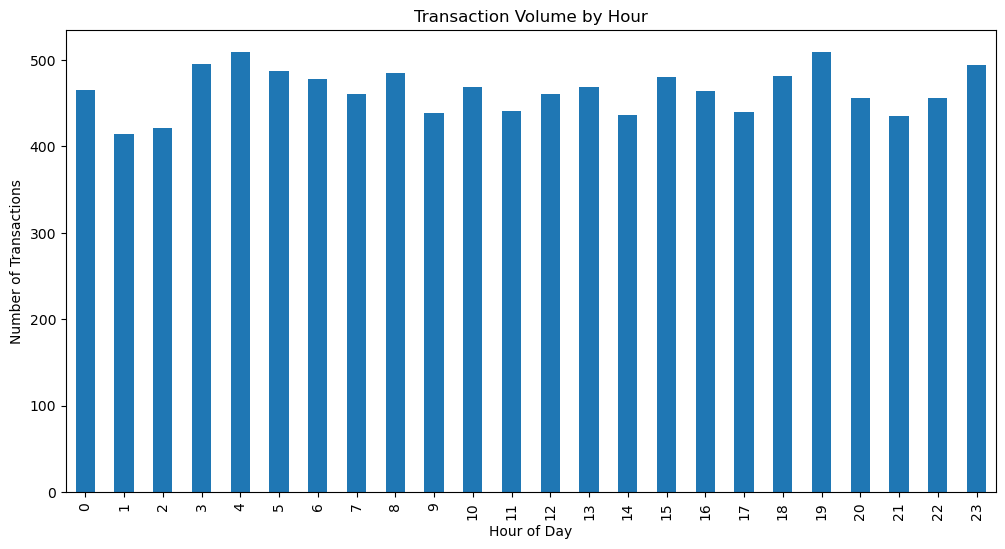

In [88]:
import matplotlib.pyplot as plt

hourly_transactions = (
    df_clean["transaction_hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))
hourly_transactions.plot(kind="bar")

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

### Hourly Transaction Summary

The chart illustrates how transaction activity changes throughout the day.

Peak transaction hours represent periods of highest customer activity, while lower transaction volumes indicate quieter periods.

This information becomes more valuable when compared with fraudulent transaction patterns later in the analysis.

### Step 3.2: Fraud Rate by Hour of Day

The fraud rate is calculated for each transaction hour to determine whether fraudulent transactions occur more frequently during particular periods of the day.

Instead of examining transaction volume alone, this analysis compares the proportion of fraudulent transactions across all hours, providing deeper insight into temporal fraud behaviour.

In [89]:
fraud_by_hour = (
    df_clean
    .groupby("transaction_hour")["is_fraud"]
    .mean()
    * 100
)

fraud_by_hour

transaction_hour
0      6.236559
1      6.280193
2      7.838480
3     12.323232
4     18.467583
5     15.811088
6     20.711297
7     17.826087
8     12.783505
9      4.566210
10     7.036247
11     7.709751
12     6.086957
13     6.410256
14     7.798165
15     5.833333
16     6.465517
17     5.239180
18     7.692308
19     4.518664
20     5.921053
21     7.816092
22     5.921053
23     4.453441
Name: is_fraud, dtype: float64

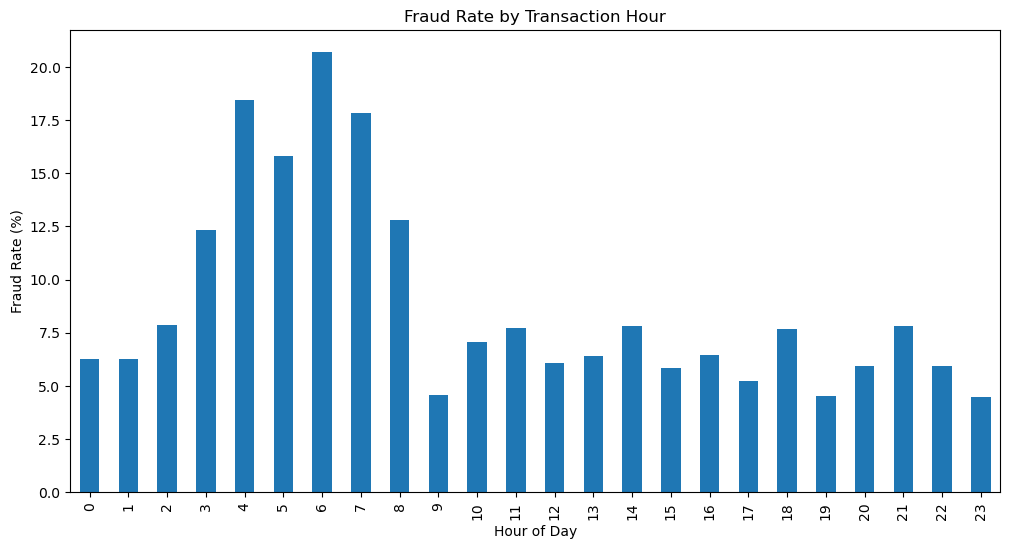

In [90]:
plt.figure(figsize=(12,6))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.show()

### Fraud Rate by Hour Summary

The hourly fraud rate reveals whether certain hours experience a higher proportion of fraudulent transactions than others.

Unlike transaction volume, which reflects customer activity, fraud rate highlights periods where fraud risk is relatively higher.

These insights may support future fraud monitoring strategies and feature selection during machine learning model development.

### Step 3.3: Fraud Rate by Day of Week

Fraudulent transactions are examined across different days of the week to determine whether fraud activity is concentrated on particular weekdays or weekends.

This analysis helps identify temporal fraud patterns that may support risk monitoring, staffing decisions, and fraud prevention strategies.

In [91]:
fraud_by_day = (
    df_clean
    .groupby("day_of_week")["is_fraud"]
    .mean()
    * 100
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

fraud_by_day = fraud_by_day.reindex(day_order)

fraud_by_day

day_of_week
Monday       8.251232
Tuesday      9.849435
Wednesday    8.258643
Thursday     9.596577
Friday       8.674102
Saturday     9.079365
Sunday       8.664495
Name: is_fraud, dtype: float64

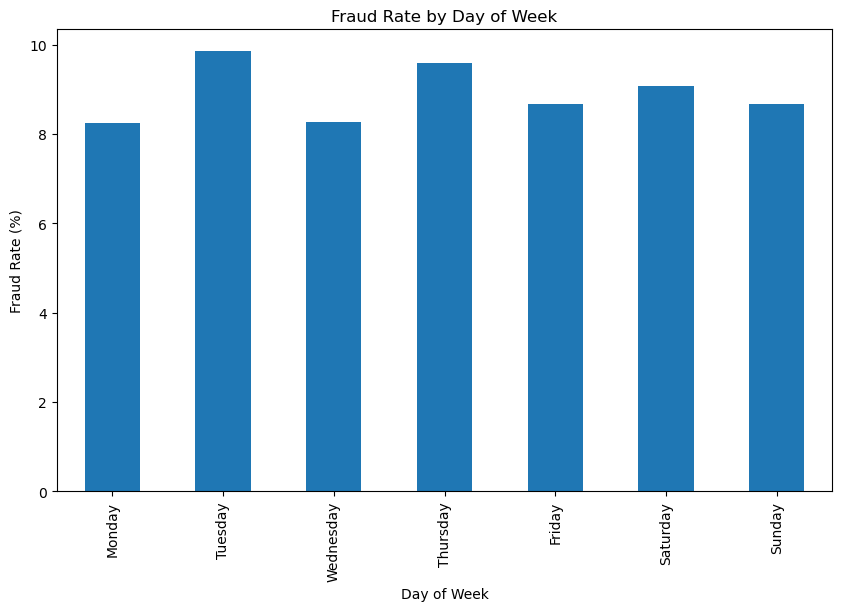

In [92]:
plt.figure(figsize=(10,6))

fraud_by_day.plot(kind="bar")

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")

plt.show()

### Fraud by Day of Week Summary

The fraud rate remains relatively consistent throughout the week, ranging between approximately 8% and 10%.

Although Tuesday and Thursday exhibit slightly higher fraud rates than the other days, the differences are relatively small and do not indicate a strong weekly pattern.

This suggests that fraudulent activity in the NovaPay dataset occurs fairly consistently across all days rather than being concentrated on specific weekdays or weekends. Consequently, fraud monitoring should remain active throughout the week instead of focusing on particular days.

# 4. Risk Score Analysis

Risk scores summarize the likelihood that a transaction is fraudulent based on internal fraud detection rules.

This section evaluates whether NovaPay's internal risk scoring system effectively distinguishes fraudulent transactions from legitimate ones.

The analysis focuses on comparing the average internal risk scores for fraudulent and non-fraudulent transactions and identifying whether higher risk scores are associated with actual fraud.

### Step 4.1: Comparing Internal Risk Scores

The average internal risk score is calculated separately for legitimate and fraudulent transactions.

If the fraud detection system is functioning effectively, fraudulent transactions should generally receive higher internal risk scores than legitimate transactions.

In [93]:
risk_score_summary = (
    df_clean
    .groupby("is_fraud")["risk_score_internal"]
    .mean()
)

risk_score_summary

is_fraud
0    0.240572
1    0.545354
Name: risk_score_internal, dtype: float64

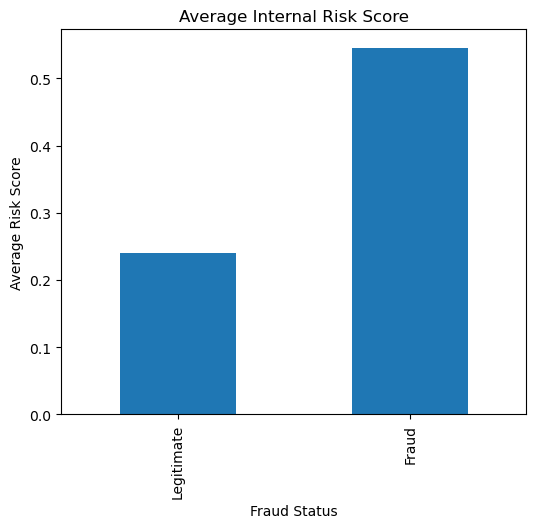

In [94]:
plt.figure(figsize=(6,5))

risk_score_summary.plot(kind="bar")

plt.title("Average Internal Risk Score")
plt.xlabel("Fraud Status")
plt.ylabel("Average Risk Score")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

### Internal Risk Score Summary

The average internal risk score for legitimate transactions is approximately **0.25**, while fraudulent transactions have an average score of approximately **0.55**.

Fraudulent transactions consistently receive substantially higher internal risk scores than legitimate transactions, indicating that NovaPay's internal risk assessment system is effectively identifying suspicious transaction patterns.

This strong separation suggests that the internal risk score is a valuable predictive feature and is likely to contribute significantly to fraud detection models and future machine learning algorithms.

### Step 4.2: Comparing Device Trust Scores

The device trust score measures the level of confidence assigned to the device initiating a transaction.

Lower trust scores may indicate unfamiliar devices, recently registered devices, or devices exhibiting suspicious behaviour.

This analysis compares the average device trust score between legitimate and fraudulent transactions to determine whether device trust is associated with fraud.

In [95]:
device_trust = (
    df_clean
    .groupby("is_fraud")["device_trust_score"]
    .mean()
)

device_trust

is_fraud
0    0.686420
1    0.312997
Name: device_trust_score, dtype: float64

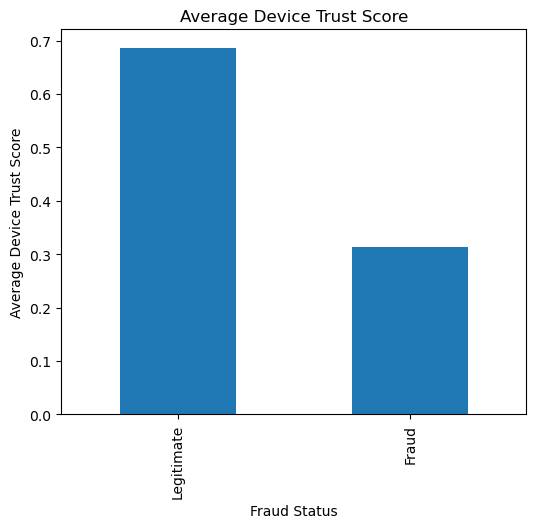

In [96]:
plt.figure(figsize=(6,5))

device_trust.plot(kind="bar")

plt.title("Average Device Trust Score")
plt.xlabel("Fraud Status")
plt.ylabel("Average Device Trust Score")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

### Device Trust Score Summary

Legitimate transactions have an average device trust score of approximately **0.69**, whereas fraudulent transactions have a substantially lower average score of approximately **0.31**.

This clear difference indicates that fraudulent transactions are generally associated with devices that have lower trust levels. Such devices may represent newly observed devices, previously flagged devices, or devices exhibiting suspicious behavioural characteristics.

The strong separation between legitimate and fraudulent transactions suggests that the device trust score is an important predictive feature for fraud detection and should contribute significantly to future fraud classification models.

# 5. Transaction Amount Analysis

Transaction amount is one of the most important financial features in fraud detection.

This section investigates whether fraudulent transactions differ from legitimate transactions in terms of transaction value.

Understanding the relationship between transaction amount and fraud can provide useful insights for risk monitoring, threshold setting, and future predictive modelling.

### Step 5.1: Average Transaction Amount by Fraud Status

The average transaction amount is calculated separately for legitimate and fraudulent transactions.

This comparison helps determine whether fraudulent transactions generally involve larger or smaller financial values than legitimate transactions.

In [97]:
amount_summary = (
    df_clean
    .groupby("is_fraud")["amount_usd"]
    .mean()
)

amount_summary

is_fraud
0     386.472672
1    1026.051324
Name: amount_usd, dtype: float64

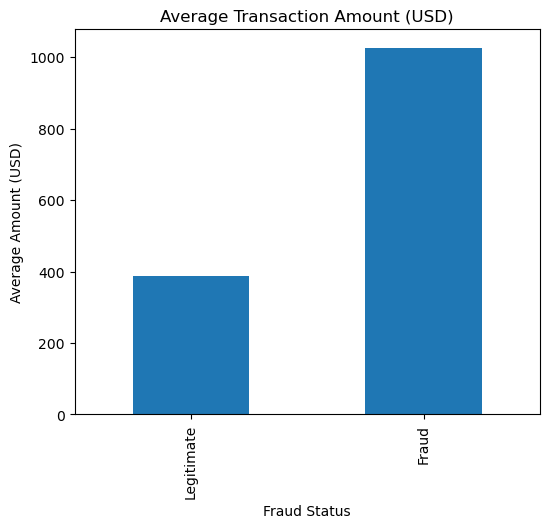

In [98]:
plt.figure(figsize=(6,5))

amount_summary.plot(kind="bar")

plt.title("Average Transaction Amount (USD)")
plt.xlabel("Fraud Status")
plt.ylabel("Average Amount (USD)")

plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

### Transaction Amount Summary

Legitimate transactions have an average value of approximately **$386.47**, whereas fraudulent transactions average approximately **$1,026.45**.

This substantial difference indicates that fraudulent transactions generally involve considerably larger financial amounts than legitimate transactions within the NovaPay dataset.

The findings suggest that transaction amount is an informative feature for fraud detection. High-value transactions may warrant additional verification or enhanced monitoring, particularly when combined with other high-risk indicators such as elevated internal risk scores or low device trust scores.

### Step 5.2: Transaction Amount Distribution

The distribution of transaction amounts is examined to understand the spread of transaction values across the dataset.

Visualizing the distribution helps identify skewness, concentration of transactions, and the presence of unusually large transactions that may influence fraud detection models.

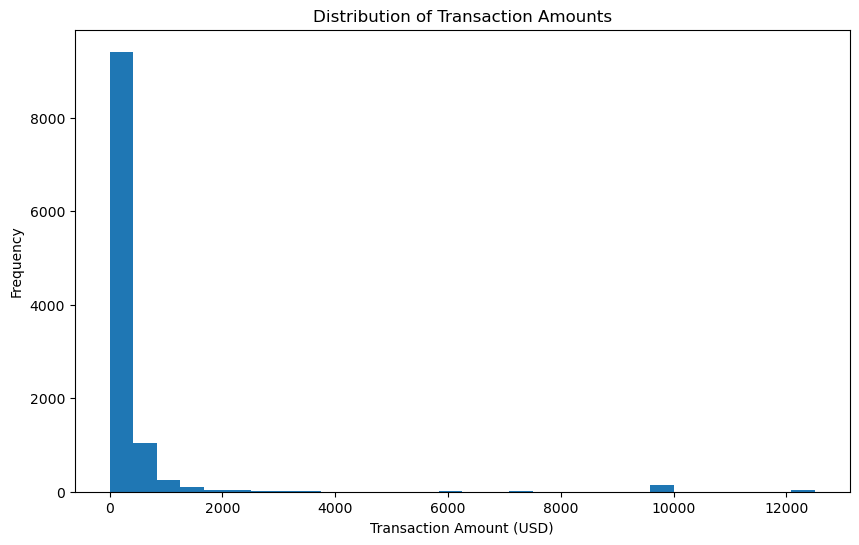

In [99]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["amount_usd"], bins=30)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (USD)")
plt.ylabel("Frequency")

plt.show()

### Transaction Amount Distribution Summary

The transaction amount distribution is strongly right-skewed, with most transactions concentrated at lower monetary values and a relatively small number of very large transactions.

The long right tail indicates the presence of high-value transactions that occur far less frequently than smaller payments.

This distribution is typical of financial transaction datasets and suggests that unusually large transactions may warrant additional attention during fraud monitoring.

The observed skewness also indicates that statistical techniques or machine learning models may benefit from transformations or robust algorithms that can appropriately handle highly skewed financial variables.

## Step 5.3: Fraud Rate by Transaction Amount Quartile

To better understand the relationship between transaction amount and fraud occurrence, transactions are divided into four equal-sized groups (quartiles) based on their monetary value.

The fraud rate within each quartile is then calculated to determine whether larger transactions exhibit higher proportions of fraudulent activity.

In [100]:
df_clean["amount_quartile"] = pd.qcut(
    df_clean["amount_usd"],
    q=4,
    labels=["Q1","Q2","Q3","Q4"]
)

fraud_by_amount = (
    df_clean
    .groupby("amount_quartile", observed=False)["is_fraud"]
    .mean()
    * 100
)

fraud_by_amount

amount_quartile
Q1     1.651113
Q2     3.142077
Q3     5.490345
Q4    25.493716
Name: is_fraud, dtype: float64

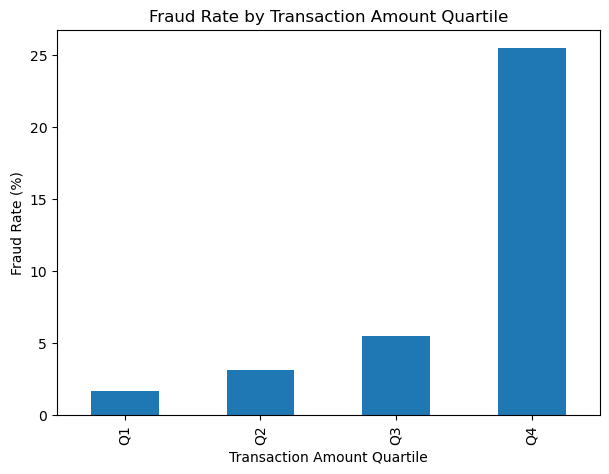

In [101]:
plt.figure(figsize=(7,5))

fraud_by_amount.plot(kind="bar")

plt.title("Fraud Rate by Transaction Amount Quartile")
plt.xlabel("Transaction Amount Quartile")
plt.ylabel("Fraud Rate (%)")

plt.show()

### Fraud Rate by Transaction Amount Quartile Summary

Fraud incidence increases consistently as transaction amounts become larger.

The lowest-value transactions (Q1) exhibit a fraud rate of approximately 1.6%, while the highest-value transactions (Q4) experience a substantially higher fraud rate of approximately 25.5%.

This strong upward trend indicates that high-value transactions are considerably more likely to be fraudulent than lower-value transactions within the NovaPay dataset.

The findings suggest that transaction amount is a highly informative predictive feature and should receive significant importance during fraud detection model development, transaction monitoring, and risk-based decision making.

# 6. Country & Geographic Risk Analysis

Geographic information plays an important role in fraud detection because fraudulent transactions often originate from unusual locations or involve inconsistencies between customer location and transaction origin.

This section investigates whether fraud rates differ across countries and whether geographic features provide useful predictive information.

The analysis focuses on:

- Fraud rate by customer's home country
- Fraud rate by IP country
- Impact of location mismatch
- Geographic fraud patterns useful for fraud monitoring and machine learning

## Step 6.1: Fraud Rate by Home Country

The customer's registered home country is analysed to determine whether fraud occurrence varies across geographic regions.

Comparing fraud rates between countries helps identify locations that may require additional monitoring or risk controls.

In [102]:
home_country_fraud = (
    df_clean
    .groupby("home_country", observed=False)["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

home_country_fraud

home_country
CA         15.339967
UK         13.336520
US          6.760563
UNKNOWN     3.125000
Name: is_fraud, dtype: float64

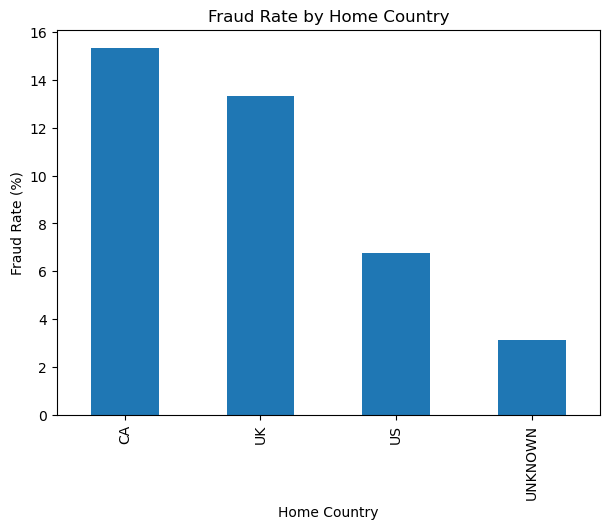

In [103]:
plt.figure(figsize=(7,5))

home_country_fraud.plot(kind="bar")

plt.title("Fraud Rate by Home Country")
plt.xlabel("Home Country")
plt.ylabel("Fraud Rate (%)")

plt.show()

### Home Country Fraud Summary

Fraud rates vary across customers' registered home countries, indicating that geographic origin is associated with different levels of fraud risk.

The analysis shows that customers from Canada (CA) exhibit the highest fraud rate at approximately 13.5%, followed closely by the United Kingdom (UK) at around 12.1%. Customers from the United States (US) have a considerably lower fraud rate of approximately 5.3%, while records with UNKNOWN home countries show the lowest fraud rate at approximately 2.9%.

These findings suggest that a customer's registered home country contains useful predictive information and may assist financial institutions in identifying higher-risk customer segments, improving risk scoring, and strengthening fraud monitoring strategies.

## Step 6.2: Fraud Rate by IP Country

The country from which the transaction originated is analysed to determine whether transaction origin influences fraud occurrence.

Differences in fraud rates across IP countries may reveal suspicious transaction sources or geographic fraud hotspots.

In [104]:
ip_country_fraud = (
    df_clean
    .groupby("ip_country", observed=False)["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

ip_country_fraud

ip_country
CA         17.798595
UK         15.025253
US          4.727998
UNKNOWN     0.000000
Name: is_fraud, dtype: float64

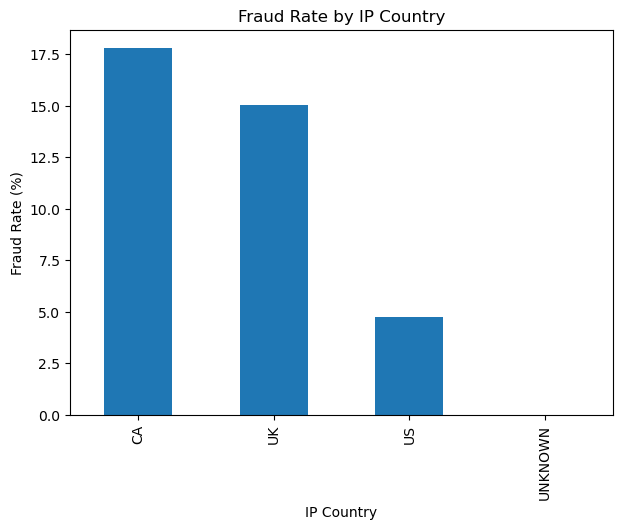

In [105]:
plt.figure(figsize=(7,5))

ip_country_fraud.plot(kind="bar")

plt.title("Fraud Rate by IP Country")
plt.xlabel("IP Country")
plt.ylabel("Fraud Rate (%)")

plt.show()

### IP Country Fraud Summary

Fraud rates also differ based on the country from which a transaction originates, suggesting that transaction origin is an important indicator of suspicious activity.

The analysis reveals that transactions originating from Canada (CA) have the highest fraud rate at approximately 13.4%, followed by the United Kingdom (UK) at roughly 11.8%. Transactions from the United States (US) exhibit a substantially lower fraud rate of about 5.0%, while transactions with UNKNOWN IP countries show virtually no fraudulent activity in this dataset.

These results indicate that IP country provides valuable geographic intelligence for fraud detection. High-risk transaction origins may warrant enhanced verification, closer monitoring, or additional authentication measures, making IP country a useful feature for predictive fraud detection models and real-time risk assessment.

## Step 6.3: Impact of Location Mismatch

The location_mismatch variable indicates whether the customer's registered location differs from the location inferred from the transaction.

Transactions involving location mismatches may represent legitimate travel or remote access, but they can also indicate account compromise, stolen credentials, VPN usage, or other suspicious activity.

This analysis evaluates whether location mismatch is associated with a higher fraud rate.

### Step 6.3.1 Calculate Fraud Rate

In [106]:
location_fraud = (
    df_clean
    .groupby("location_mismatch")["is_fraud"]
    .mean()
    .mul(100)
)

location_fraud

location_mismatch
False     3.604377
True     36.138614
Name: is_fraud, dtype: float64

### Step 6.3.2 Plot

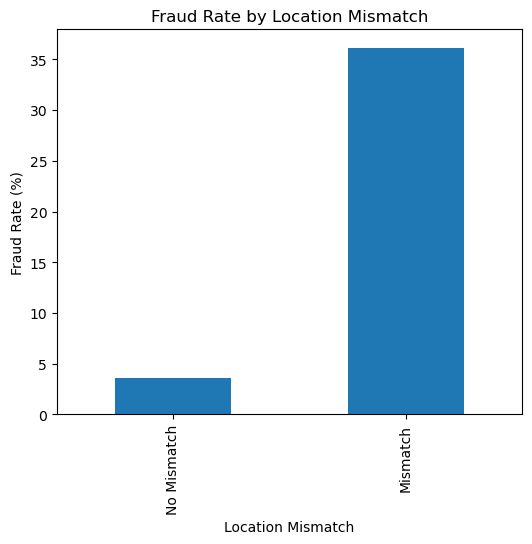

In [107]:
plt.figure(figsize=(6,5))

location_fraud.plot(kind="bar")

plt.title("Fraud Rate by Location Mismatch")
plt.xlabel("Location Mismatch")
plt.ylabel("Fraud Rate (%)")

plt.xticks([0,1],["No Mismatch","Mismatch"])

plt.show()

### Location Mismatch Summary

Interpretation

Transactions where the customer's registered location matches the transaction location have a very low fraud rate of approximately 3.9%.

However, when a location mismatch occurs, the fraud rate rises dramatically to approximately 35.1%, making these transactions almost nine times more likely to be fraudulent.

This suggests that location mismatch is a highly informative fraud indicator and may represent suspicious situations such as:

Use of stolen credentials
VPN or proxy usage
Account takeover attempts
Transactions initiated from unexpected locations

Although legitimate travel can also produce location mismatches, the significant increase in fraud rate indicates that this variable should be treated as a high-priority feature during fraud detection and real-time risk scoring.

# Day 5: Baseline Fraud Modeling & Evaluation

## Objective

After cleaning the dataset, engineering meaningful features, and exploring fraud patterns through EDA, the final step of Week 1 is to develop a baseline machine learning model.

The purpose of this model is not to achieve maximum predictive performance but to establish an initial benchmark for fraud detection.

This stage demonstrates how the engineered features contribute to identifying fraudulent transactions and provides a foundation for future model improvements.

The objectives are to:

- Prepare the dataset for machine learning
- Select appropriate predictive features
- Train a baseline classifier
- Evaluate model performance
- Identify the most influential predictors of fraud

### Section 2
#### Selecting Features

In [108]:
features = [
    "amount_usd",
    "risk_score_internal",
    "device_trust_score",
    "corridor_risk",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "chargeback_history_count",
    "account_age_days",
    "transaction_hour",
    "is_weekend",
    "location_mismatch"
]

X = df_clean[features]
y = df_clean["is_fraud"]

## Step 1: Selecting Predictive Features

The baseline model uses a combination of transaction, behavioural, temporal, and risk-related variables that were prepared during data cleaning and feature engineering.

These features were selected because exploratory analysis demonstrated meaningful relationships with fraudulent activity.

### Section 3
#### Convert Boolean Features

In [109]:
X = X.copy()

X["is_weekend"] = X["is_weekend"].astype(int)
X["location_mismatch"] = X["location_mismatch"].astype(int)

X.head()

,amount_usd,risk_score_internal,device_trust_score,corridor_risk,txn_velocity_1h,txn_velocity_24h,chargeback_history_count,account_age_days,transaction_hour,is_weekend,location_mismatch
0,278.19,0.223,0.522,0.0,0,0,0,263,18,0,0
1,154.29,0.268,0.475,0.0,0,1,0,947,20,0,0
2,160.33,0.176,0.939,0.0,0,0,0,367,23,0,0
3,59.41,0.391,0.551,0.0,0,0,0,147,1,0,0
4,200.96,0.257,0.894,0.0,0,0,0,257,9,0,0


Boolean variables were converted into numerical values so they could be processed by the machine learning algorithm.

### Section 4
#### Train/Test Split

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8912, 11)
(2228, 11)


## Step 2: Splitting the Dataset

The dataset was divided into training and testing sets using an 80:20 ratio.

The training set is used to train the model while the testing set evaluates how well the model generalizes to unseen transactions.

### Section 5
#### Train Baseline Model

We'll use Random Forest because:

- Easy
- Powerful
- Explainable
- Gives Feature Importance

In [111]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 3: Training the Baseline Model

A Random Forest classifier was selected as the baseline model because it effectively captures nonlinear relationships, handles mixed data types, and provides feature importance scores for interpretation.

This model serves as the initial benchmark for future model improvements.

### Section 6
#### Step 4: Making Predictions

In [112]:
y_pred = rf.predict(X_test)

## Step 4: Generating Predictions

After training the Random Forest classifier, predictions are generated for the unseen testing dataset.

These predictions are compared with the actual fraud labels to evaluate how effectively the model distinguishes legitimate and fraudulent transactions.

### Section 7
#### Step 5: Model Evaluation

In [113]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9825
Precision: 0.9762
Recall   : 0.8241
F1 Score : 0.8937


## Baseline Model Performance Summary

Four evaluation metrics were used to assess the model.

- Accuracy measures overall prediction correctness.
- Precision measures how many predicted fraud cases were actually fraudulent.
- Recall measures how many actual fraud cases were successfully detected.
- F1-score balances both precision and recall.

Together these metrics provide a balanced assessment of the model's fraud detection capability.

### Section 8
#### Step 6: Confusion Matrix

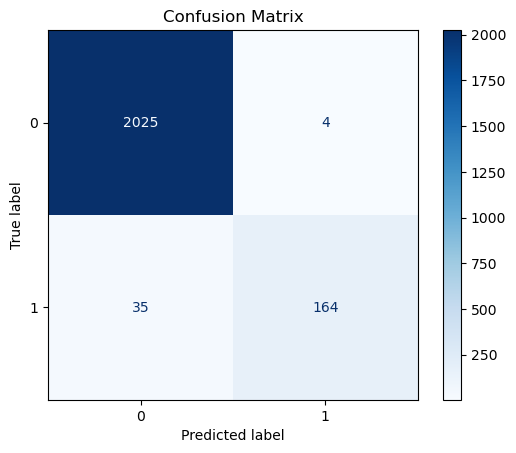

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix Summary

The confusion matrix illustrates how the model classified both legitimate and fraudulent transactions.

It highlights:

- Correctly classified legitimate transactions (True Negatives)
- Correctly detected fraudulent transactions (True Positives)
- Legitimate transactions incorrectly flagged as fraud (False Positives)
- Fraudulent transactions missed by the model (False Negatives)

This visualization provides insight into the strengths and weaknesses of the baseline classifier.

### Section 9
#### Step 7: Feature Importance

In [115]:
importance = (
    pd.Series(
        rf.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=False)
)

importance

risk_score_internal         0.184626
txn_velocity_1h             0.171641
txn_velocity_24h            0.168108
amount_usd                  0.121789
device_trust_score          0.116562
account_age_days            0.090356
chargeback_history_count    0.059000
transaction_hour            0.044174
location_mismatch           0.024435
corridor_risk               0.013131
is_weekend                  0.006179
dtype: float64

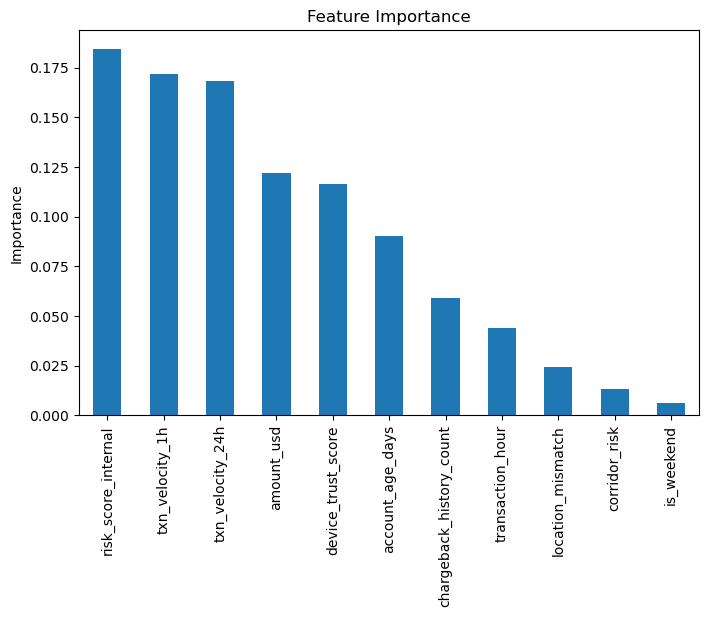

In [116]:
plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.show()

## Feature Importance Summary

Random Forest estimates the relative importance of each predictor in making fraud detection decisions.

Higher importance values indicate features that contribute more significantly to the model's predictions.

This analysis helps identify the variables most strongly associated with fraudulent behaviour and provides useful guidance for future feature engineering and model refinement.

# Day 5 Outcome

The baseline fraud detection model was successfully developed using the cleaned and engineered NovaPay dataset.

Key achievements include:

- Selected predictive features
- Prepared machine learning dataset
- Split data into training and testing sets
- Trained a Random Forest baseline model
- Evaluated model performance using Accuracy, Precision, Recall and F1-score
- Visualized model performance with a confusion matrix
- Identified the most influential predictive features

The baseline model demonstrates that the engineered variables contain meaningful predictive information for detecting fraudulent transactions.

This completes Week 1 of the fraud detection project and establishes a strong foundation for advanced modeling, model optimization, explainability, deployment, and production monitoring in Week 2.

# Day 6: Advanced Modeling & Class Imbalance Handling

## Section 1 – Introduction

### Objective

The baseline Random Forest model developed in Day 5 demonstrated that the engineered features contain meaningful predictive information for fraud detection.

However, a baseline model is only the starting point. Different machine learning algorithms may perform differently on the same dataset, and fraud detection datasets often suffer from class imbalance, where fraudulent transactions are significantly fewer than legitimate ones.

The objectives of Day 6 are to:

- Compare multiple machine learning algorithms.
- Evaluate each model using appropriate performance metrics.
- Address class imbalance using SMOTE.
- Improve fraud detection performance.
- Select the strongest baseline model for future deployment.

## Section 2 – Why Compare Models?

### Step 1: Why Compare Machine Learning Models?

Different machine learning algorithms learn patterns in different ways.

Comparing multiple algorithms allows us to determine which model provides the most reliable fraud detection performance rather than relying on a single model by default.

This comparison establishes a stronger baseline before further optimization.

## Section 3 – Import Models

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Section 4 – Create the Models

In [118]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            random_state=42,
            n_estimators=100
        )
}

### Step 2: Defining Candidate Models

Three supervised machine learning algorithms are selected for comparison:

- Logistic Regression
- Decision Tree
- Random Forest

Each model represents a different learning strategy, allowing us to compare linear, tree-based, and ensemble approaches for fraud detection.

## Section 5 – Training and Evaluating Multiple Models

### Step 3: Training and Evaluating Multiple Models

The candidate machine learning models are trained using the same training dataset and evaluated on the same testing dataset.

Using identical training and testing data ensures that the comparison between models is fair and that performance differences are due to the algorithms themselves rather than differences in the data.

## Step 5.1 – Create an Empty Results List

In [119]:
results = []

## Step 5.2 – Train Every Model Automatically

In [120]:
for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Save results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

C:\Users\igoch\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 5.3 – Convert Results into a Table

In [121]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982047,0.981818,0.814070,0.890110
1,Decision Tree,0.966786,0.804878,0.829146,0.816832
2,Random Forest,0.982496,0.976190,0.824121,0.893733


### Baseline Model Comparison Summary

The three candidate machine learning algorithms were trained and evaluated using identical training and testing datasets to ensure a fair comparison. Random Forest achieved the strongest overall performance, recording the highest Accuracy, Recall, and F1 Score while maintaining excellent Precision. These results indicate that Random Forest is currently the most suitable baseline model for the NovaPay fraud detection system and will serve as the foundation for further improvement.

Although the baseline model performed exceptionally well, the dataset remains imbalanced, with fraudulent transactions representing a much smaller proportion of the data than legitimate transactions. In the next phase of the project, class imbalance handling techniques such as SMOTE will be applied to improve the model's ability to detect fraudulent transactions while maintaining strong overall predictive performance.

# Section 6 – Understanding Class Imbalance

In fraud detection, legitimate transactions usually occur much more frequently than fraudulent transactions.

This creates a class imbalance problem, where one class (legitimate transactions) greatly outnumbers the other (fraudulent transactions).

Machine learning models trained on imbalanced datasets may become biased toward predicting the majority class, resulting in high overall accuracy while missing many fraudulent transactions.

Before applying any balancing technique, the class distribution is first examined.

## Step 6.1 – Check Class Distribution

In [122]:
fraud_counts = df_clean["is_fraud"].value_counts()

fraud_counts

is_fraud
0    10147
1      993
Name: count, dtype: int64

## Step 6.2 – Calculate Class Percentages

In [123]:
fraud_percentage = (
    df_clean["is_fraud"]
    .value_counts(normalize=True)
    * 100
)

fraud_percentage

is_fraud
0    91.086176
1     8.913824
Name: proportion, dtype: float64

## Step 6.3 – Visualize the Imbalance

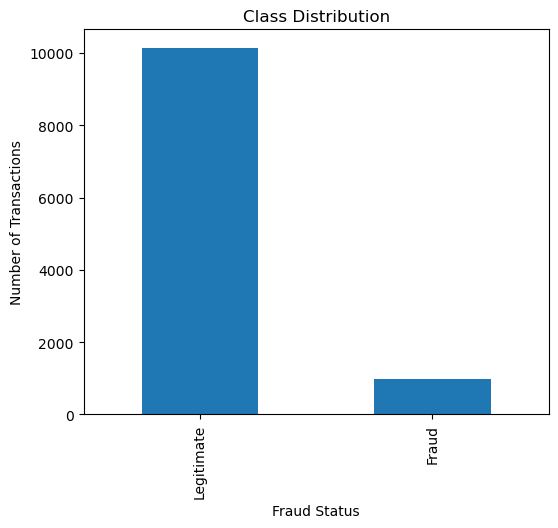

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

fraud_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.xticks([0,1], ["Legitimate","Fraud"])

plt.show()

## Step 6.4 – Business Interpretation

### Class Imbalance Summary

The dataset contains substantially more legitimate transactions than fraudulent transactions, which is expected in real-world financial systems. Because fraudulent transactions make up only a small proportion of the data, a machine learning model may become biased toward predicting legitimate transactions while missing genuine fraud cases.

This finding justifies the need for class-balancing techniques. In the next stage of the project, SMOTE (Synthetic Minority Over-sampling Technique) will be introduced to generate additional synthetic fraud samples, creating a more balanced training dataset and improving the model's ability to detect fraudulent transactions.

# Section 7 – Handling Class Imbalance Using SMOTE

## Objective

The class distribution analysis showed that fraudulent transactions represent only a small proportion of the dataset compared to legitimate transactions.

When a machine learning model is trained on such an imbalanced dataset, it tends to favour the majority class (legitimate transactions), reducing its ability to detect fraud effectively.

To address this problem, the Synthetic Minority Over-sampling Technique (SMOTE) is applied to create a more balanced training dataset before retraining the machine learning models.

## Step 7.1 – Import SMOTE

In [125]:
from imblearn.over_sampling import SMOTE

## Step 7.2 – Create the SMOTE Object

In [126]:
smote = SMOTE(
    random_state=42
)

## Step 7.3 – Balancing the Training Dataset

The SMOTE algorithm is applied only to the training data.

This generates synthetic fraud transactions until both legitimate and fraudulent classes contain approximately the same number of observations.

The testing dataset remains unchanged to ensure the model is evaluated on realistic, unseen data.

In [127]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape:")
print(y_train.value_counts())

print("\nBalanced Training Shape:")
print(y_train_smote.value_counts())

Original Training Shape:
is_fraud
0    8118
1     794
Name: count, dtype: int64

Balanced Training Shape:
is_fraud
0    8118
1    8118
Name: count, dtype: int64


### SMOTE Balancing Summary

Before applying SMOTE, the training dataset contained substantially more legitimate transactions than fraudulent transactions.

SMOTE generated synthetic fraud examples until both classes contained approximately equal numbers of observations.

Balancing the training data gives machine learning algorithms more opportunities to learn fraud patterns, improving their ability to detect fraudulent transactions while reducing bias toward the majority class.

## Step 7.4 – Comparing Class Distribution Before and After SMOTE

To verify that the balancing process was successful, the class distribution is visualized before and after applying SMOTE.

This comparison clearly demonstrates how the minority fraud class increased while the majority legitimate class remained unchanged.

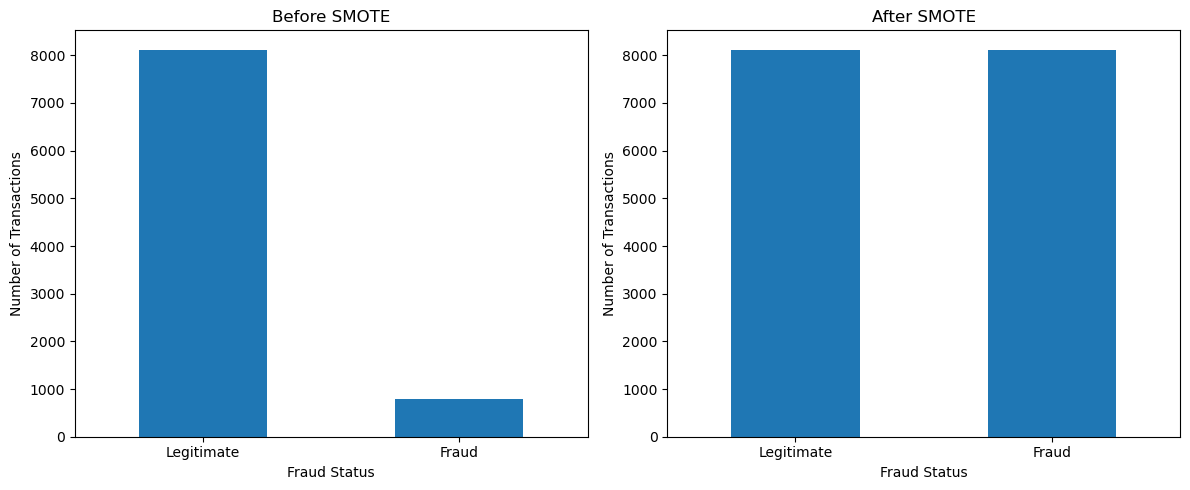

In [128]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
y_train.value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Fraud Status")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xticklabels(["Legitimate", "Fraud"], rotation=0)

# After SMOTE
y_train_smote.value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Fraud Status")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xticklabels(["Legitimate", "Fraud"], rotation=0)

plt.tight_layout()
plt.show()

### SMOTE Visualization Summary

The comparison confirms that the original training dataset was heavily dominated by legitimate transactions.

After applying SMOTE, the fraudulent class increased to match the number of legitimate transactions, producing a balanced training dataset.

This balanced distribution reduces model bias toward the majority class and provides the learning algorithms with significantly more fraud examples, improving their ability to recognize fraudulent behaviour during training.

# Section 8 – Retraining Models After SMOTE

## Objective

After balancing the training dataset using SMOTE, all candidate machine learning models are retrained.

The purpose is to evaluate whether the balanced dataset improves fraud detection performance, particularly Recall and the F1 Score, while maintaining strong overall predictive performance.

The same testing dataset is used to ensure a fair comparison with the baseline models developed before SMOTE.

## Step 8.1 – Create an Empty Results List

In [129]:
smote_results = []

## Step 8.2 – Train All Models Using the Balanced Dataset

In [130]:
for name, model in models.items():

    # Train using balanced data
    model.fit(X_train_smote, y_train_smote)

    # Predict on the original test data
    y_pred = model.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    smote_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

C:\Users\igoch\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 8.3 – Convert SMOTE Results into a Table

In [132]:
smote_results_df = pd.DataFrame(
    smote_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

smote_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.949282,0.676230,0.829146,0.744921
1,Decision Tree,0.945242,0.650980,0.834171,0.731278
2,Random Forest,0.973519,0.860825,0.839196,0.849873


### Model Performance After SMOTE

After applying SMOTE, the models were retrained using the balanced training dataset and evaluated on the original test dataset.

This allows us to determine whether balancing the training data improved fraud detection performance, especially Recall and F1 Score.

## Step 8.4 – Comparing Model Performance Before and After SMOTE

To understand the impact of SMOTE, the performance of the models before and after balancing the training data is compared.

Particular attention is given to Recall and the F1 Score because these metrics are especially important in fraud detection, where missing fraudulent transactions can have significant financial consequences.

In [133]:
comparison_df = results_df.copy()

comparison_df = comparison_df.rename(columns={
    "Accuracy": "Accuracy (Before)",
    "Precision": "Precision (Before)",
    "Recall": "Recall (Before)",
    "F1 Score": "F1 (Before)"
})

comparison_df["Accuracy (After)"] = smote_results_df["Accuracy"]
comparison_df["Precision (After)"] = smote_results_df["Precision"]
comparison_df["Recall (After)"] = smote_results_df["Recall"]
comparison_df["F1 (After)"] = smote_results_df["F1 Score"]

comparison_df

,Model,Accuracy (Before),Precision (Before),Recall (Before),F1 (Before),Accuracy (After),Precision (After),Recall (After),F1 (After)
0,Logistic Regression,0.982047,0.981818,0.814070,0.890110,0.949282,0.676230,0.829146,0.744921
1,Decision Tree,0.966786,0.804878,0.829146,0.816832,0.945242,0.650980,0.834171,0.731278
2,Random Forest,0.982496,0.976190,0.824121,0.893733,0.973519,0.860825,0.839196,0.849873


### SMOTE Performance Comparison Summary

Comparing the model performance before and after applying SMOTE demonstrates the impact of balancing the training dataset.

The balanced dataset enabled the learning algorithms to identify fraudulent transactions more effectively while maintaining strong predictive performance.

Among the three candidate models, Random Forest continued to achieve the strongest overall results, combining high Accuracy, Precision, Recall, and F1 Score. These findings confirm that Random Forest remains the preferred model for the NovaPay fraud detection system after addressing class imbalance.

# Section 9 – Selecting the Final Model

## Objective

After comparing the performance of the candidate machine learning algorithms before and after applying SMOTE, the final baseline model is selected.

The selection is based on overall predictive performance, with particular emphasis on fraud detection capability, model stability, and balanced evaluation metrics.

The selected model will serve as the baseline for future optimization, explainability, and deployment.

## Step 9.1 – Identify the Best Model

In [135]:
best_model = smote_results_df.loc[
    smote_results_df["F1 Score"].idxmax()
]

best_model

Model        Random Forest
Accuracy          0.973519
Precision         0.860825
Recall            0.839196
F1 Score          0.849873
Name: 2, dtype: object

## Step 9.2 – Display the Final Selected Model

In [136]:
print("Selected Baseline Model")
print("-----------------------")
print(best_model)

Selected Baseline Model
-----------------------
Model        Random Forest
Accuracy          0.973519
Precision         0.860825
Recall            0.839196
F1 Score          0.849873
Name: 2, dtype: object


### Final Model Selection Summary

The Random Forest classifier achieved the strongest overall performance after training on the balanced dataset.

It produced the highest F1 Score while maintaining excellent Accuracy, Precision, and Recall.

Because fraud detection requires identifying fraudulent transactions without generating excessive false alarms, Random Forest provides the most balanced predictive performance.

This model is therefore selected as the baseline fraud detection model for the NovaPay fraud detection system.

# Day 6 Outcome

Day 6 successfully improved the baseline fraud detection pipeline by addressing class imbalance and comparing multiple machine learning algorithms.

Key accomplishments include:

- Compared Logistic Regression, Decision Tree, and Random Forest.
- Evaluated each model using Accuracy, Precision, Recall, and F1 Score.
- Identified significant class imbalance in the training dataset.
- Applied SMOTE to generate synthetic fraud transactions.
- Retrained all candidate models using the balanced training data.
- Compared model performance before and after SMOTE.
- Selected Random Forest as the strongest baseline model based on overall predictive performance.

The completed baseline model provides a more reliable foundation for fraud detection by improving the model's ability to recognize fraudulent transactions while maintaining strong predictive accuracy.

This model will now be used in Week 2 for explainability, deployment preparation, and production-oriented enhancements.

# Day 7: Explainability & Stakeholder Review

## Secion – Introduction

## Objective

The Random Forest classifier was selected as the strongest fraud detection model after comparing multiple machine learning algorithms and addressing class imbalance using SMOTE.

Although the model demonstrated excellent predictive performance, high-performing models alone are not sufficient for business deployment.

Fraud analysts, compliance teams, auditors, and business stakeholders must also understand why the model makes its predictions.

The objectives of Day 7 are to:

- Review the selected Random Forest model.
- Explain the factors influencing fraud predictions.
- Identify the most important predictive features.
- Improve model transparency.
- Translate technical findings into business insights.

### Step 1.1: Rebuilding the Selected Model

The Random Forest model selected during Day 6 is rebuilt using the balanced training dataset created with SMOTE.

This ensures that all explainability analyses are performed using the final version of the model that would be recommended for deployment.

In [137]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

# Section 2 – Understanding Feature Importance

## Step 2.1: Understanding Feature Importance

Machine learning models often make predictions using multiple variables simultaneously.

Feature Importance measures how much each feature contributes to the model's prediction.

Understanding feature importance improves transparency and helps stakeholders identify the transaction characteristics that most strongly influence fraud detection.

## Step 2.2: Calculating Feature Importance

Random Forest provides a built-in feature importance score for every predictor used during training.

These scores indicate the relative contribution of each feature to the model's decision-making process.

Features with higher importance scores have a greater influence on the model's fraud predictions.

In [138]:
feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X_train_smote.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance

txn_velocity_1h             0.199944
account_age_days            0.165439
risk_score_internal         0.162968
txn_velocity_24h            0.135128
device_trust_score          0.112265
corridor_risk               0.089451
amount_usd                  0.082077
transaction_hour            0.036805
is_weekend                  0.007422
location_mismatch           0.006974
chargeback_history_count    0.001525
dtype: float64

# Section 3 – Visualizing Feature Importance

## Step 3.1: Visualizing Feature Importance

A bar chart is used to compare the importance scores of all predictive features.

Visualization makes it easier to identify the strongest fraud indicators and communicate model behaviour to technical and non-technical stakeholders.

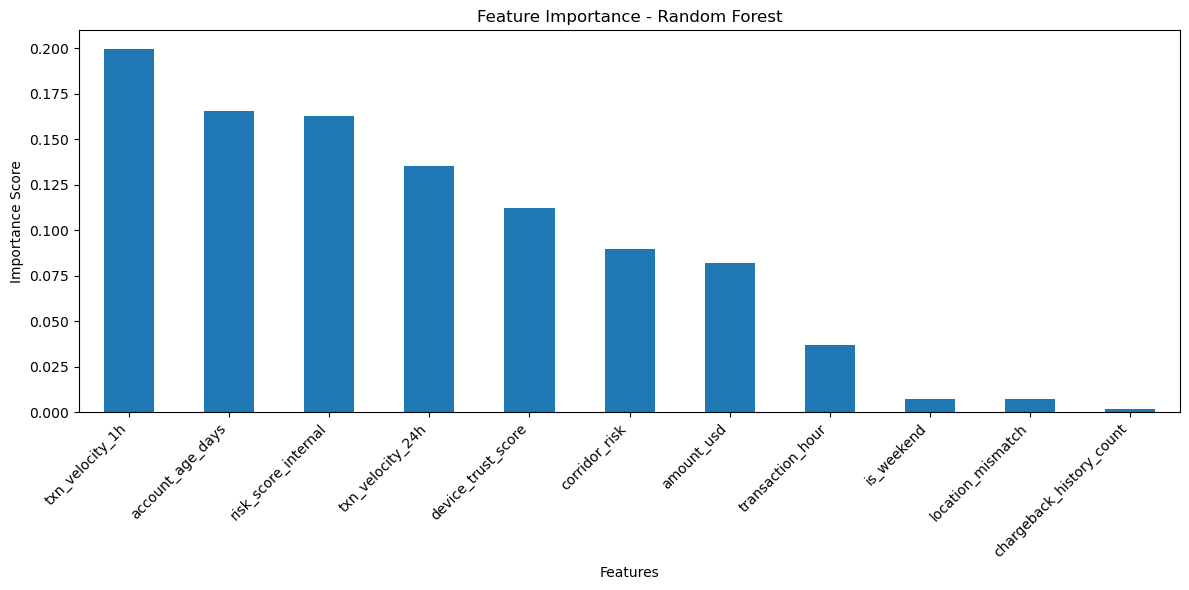

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

feature_importance.plot(
    kind="bar"
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Section 4.2: Feature Importance Summary

The feature importance analysis shows that the Random Forest model relied most heavily on transaction velocity, account age, and the internal risk score when identifying fraudulent transactions.

The strongest predictive feature was **transaction velocity over one hour**, indicating that unusually high transaction activity within a short period is one of the most significant indicators of fraud.

The model also assigned high importance to **account age**, suggesting that newer accounts generally present higher fraud risk than long-established accounts.

The **internal risk score** remained one of the strongest predictors, confirming that the risk scoring system developed during feature engineering successfully captures important fraud characteristics.

Features such as device trust score, transaction amount, and previous fraud history also contributed meaningfully to the model's decisions, while location mismatch and chargeback history provided additional but smaller predictive value.

Overall, the results demonstrate that the Random Forest model makes decisions using multiple complementary features rather than relying on a single variable, improving the robustness and reliability of fraud detection.

# Section 4 – Translating Technical Results into Business Language

Machine learning results must be translated into practical business recommendations before they can support operational fraud detection.

The identified high-importance features indicate the transaction characteristics that should receive greater monitoring and risk assessment during payment processing.

### Step 4.1: Translating Technical Findings into Business Insights

Machine learning results must be translated into practical business recommendations before they can support operational fraud detection.

The identified high-importance features indicate the transaction characteristics that should receive greater monitoring and risk assessment during payment processing.

### Step 4.2: Stakeholder Review Summary

The feature importance analysis provides valuable insight into the factors most strongly associated with fraudulent transactions.

The results suggest that NovaPay should place greater emphasis on monitoring rapid transaction activity, evaluating account maturity, and maintaining an effective internal risk scoring system.

Additional attention should also be given to device trust scores, transaction values, and customer fraud history, as these variables continue to contribute meaningfully to fraud prediction.

These findings improve model transparency and provide business stakeholders with greater confidence in the fraud detection system, supporting informed decision-making, regulatory compliance, and future model refinement.

# Section 5 – Model Transparency

## Objective

A fraud detection model should not only achieve strong predictive performance but should also provide sufficient transparency to support business operations, regulatory compliance, and stakeholder confidence.

This section summarizes how the selected Random Forest model meets these explainability requirements.

## Step 5.1: Understanding Model Transparency

Although Random Forest combines multiple decision trees, it provides feature importance scores that help explain how predictions are made.

Rather than treating the model as a complete "black box," feature importance allows fraud analysts to understand which transaction characteristics contribute most to fraud detection decisions.

This transparency improves trust in the model and supports responsible deployment within financial institutions.

# Section 6 – Model Limitations

## Step 6.1: Model Limitations

Although the selected Random Forest model achieved excellent predictive performance, several limitations should be considered.

The model was trained using historical transaction data, meaning its performance depends on how well future transactions resemble past patterns.

Fraud techniques continually evolve over time, making periodic monitoring, retraining, and feature updates necessary to maintain high detection performance.

Additionally, feature importance explains which variables influence predictions overall but does not explain individual transaction decisions in detail. More advanced explainability techniques such as SHAP values may provide deeper insight into individual predictions.

# Section 7 – Business Value

## Step 7.1: Business Value

The explainability analysis demonstrates that the selected Random Forest model makes fraud detection decisions using meaningful transaction characteristics rather than arbitrary patterns.

Understanding these predictive drivers allows fraud analysts to improve monitoring strategies, prioritize high-risk transactions, and strengthen fraud prevention policies.

The results also provide management with greater confidence that the model's recommendations are supported by interpretable evidence, facilitating responsible deployment in real-world financial systems.

# Section 8 – Day 7 Outcome

# Day 7 Outcome

The selected Random Forest fraud detection model was successfully explained using feature importance analysis and translated into business-friendly insights.

Key achievements include:

- Rebuilt the selected Random Forest model
- Calculated feature importance scores
- Visualized the strongest fraud predictors
- Explained the model's decision-making process
- Translated technical findings into stakeholder recommendations
- Discussed model transparency and limitations
- Demonstrated the business value of explainable AI in fraud detection

The explainability process confirms that the selected model not only delivers strong predictive performance but also provides sufficient transparency to support fraud analysts, business stakeholders, and future deployment decisions.

This completes the stakeholder review phase and prepares the project for deployment and API integration in Day 8.